In [6]:
# import data 
import pandas as pd
from pathlib import Path 

# find current working directory
data_path1 = Path.cwd().parent / 'Data' / 'linear.csv'
data_path2 = Path.cwd().parent/ 'Data' / 'non_linear.csv'
data_path3 = Path.cwd().parent / 'Data' / 'target.csv'

# load data into respective objects
linear = pd.read_csv(data_path1)
non_linear = pd.read_csv(data_path2)
target = pd.read_csv(data_path3)


In [24]:
# train linear dataset
from sklearn.model_selection import train_test_split

# target varible 
Y = target[['Survived']]

# inputs 
X = linear.copy()

# 70/30 split 
X_train, X_test1, Y_train, Y_test = train_test_split(X, Y, test_size = 0.3, shuffle = True, random_state = 42)


In [20]:
# import sklearn and configure model for the best parameters
from sklearn.linear_model import LogisticRegression 

# instanstation process 
lr = LogisticRegression(C=10, penalty='l1', solver='liblinear')

# fit model on the training data
lr.fit(X_train, Y_train)


C:\Users\dmiracju\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(C=10, penalty='l1', solver='liblinear')

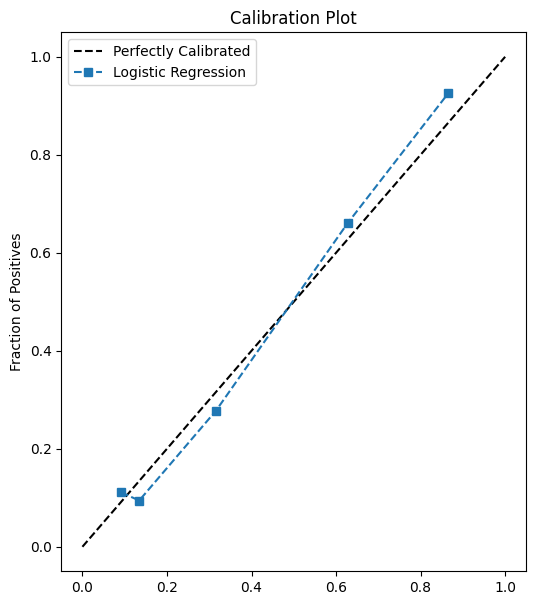

In [30]:
# calculate calibaration curve using probabilities for kogistic regression 
from sklearn.calibration import calibration_curve

# get the predicited probabilities for the positive class
lr_probs = lr.predict_proba(X_test1)[:, 1] # logistic Regression probability outputs  

# calculate the curve plots 
lr_prob, lr_pred = calibration_curve(Y_test, lr_probs, n_bins = 5, strategy= 'quantile') # n_bins = 10 is standard for small to medium datasets

# plot results 
import matplotlib.pyplot as plt
plt.figure(figsize = (6,7))
plt.plot([0,1], [0,1], 'k--', label = 'Perfectly Calibrated')
plt.plot(lr_pred, lr_prob, 's--', label = 'Logistic Regression')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Plot')
plt.legend()
plt.show()

In [31]:
# training phase for non linear dataset 

# target variable
Y = target['Survived']

# inputs 
X = non_linear.copy() 

# 70/30 split 
X_train, X_test2, Y_train, Y_test = train_test_split(X, Y, test_size = 0.3, shuffle = True, random_state = 42)


In [ ]:
# Deploy SVM with the best settings 
from sklearn.svm import SVC

# instantation process 
svm = SVC(C=10, gamma=1)

# fit model onto data
svm.fit(X_train, Y_train)


SVC(C=10, gamma=1)

In [ ]:
# calculate the calibration curve for SVM model 
from sklearn.calibration import CalibratedClassifierCV

# calculate calibration curve 
calibrated_svc = CalibratedClassifierCV(svm, method = 'sigmoid', cv = 5)

# fit data on model 
